# EDA — 가설1: 배송 지연 경험과 이탈

> **가설**: 약속된 배송 예정일보다 실제 배송이 늦어진 고객은 이탈률이 높을 것이다.

---
## 1. 라이브러리 & 시각화 설정 / 데이터 로드

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

plt.style.use('seaborn-v0_8')
sns.set_theme(font_scale=1.5)

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# outputs 폴더 생성 (없으면)
os.makedirs('../outputs', exist_ok=True)

# 데이터 로드
orders = pd.read_csv('../data/raw/olist_orders_dataset.csv', parse_dates=[
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
])
customers = pd.read_csv('../data/raw/olist_customers_dataset.csv')

print("로드 완료")
print(f"  orders   : {orders.shape}")

로드 완료
  orders   : (99441, 8)


---
## 2. orders

In [2]:
# order_status 분포 → delivered만 사용
print("=== order_status 분포 ===")
status_counts = orders['order_status'].value_counts()
print(status_counts)
delivered_ratio = status_counts.get('delivered', 0) / len(orders)
print(f"\ndelivered 비율: {delivered_ratio:.1%}")

# 전체 날짜 범위
print("\n=== 주문 날짜 범위 ===")
print(f"최소: {orders['order_purchase_timestamp'].min()}")
print(f"최대: {orders['order_purchase_timestamp'].max()}")

# 날짜 필드 결측치
print("\n=== 날짜 필드 결측치 ===")
date_cols = ['order_delivered_customer_date', 'order_estimated_delivery_date']
missing_dates = orders[date_cols].isnull().sum()
missing_pct   = orders[date_cols].isnull().mean()
for col in date_cols:
    print(f"{col}: {missing_dates[col]:,}건 ({missing_pct[col]:.1%})")

=== order_status 분포 ===
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

delivered 비율: 97.0%

=== 주문 날짜 범위 ===
최소: 2016-09-04 21:15:19
최대: 2018-10-17 17:30:18

=== 날짜 필드 결측치 ===
order_delivered_customer_date: 2,965건 (3.0%)
order_estimated_delivery_date: 0건 (0.0%)


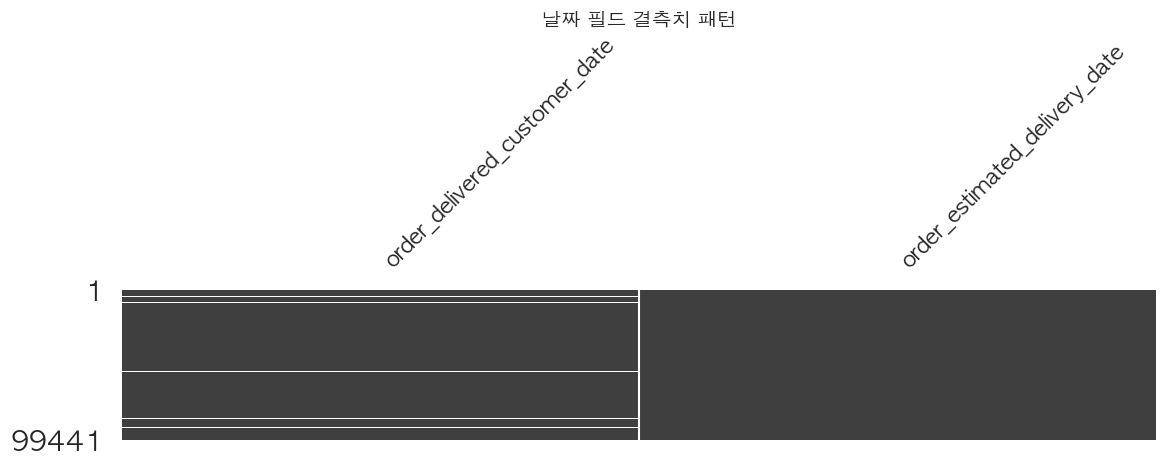

In [3]:
# 날짜 필드 결측치 시각화
fig, ax = plt.subplots(figsize=(12, 5))
msno.matrix(orders[date_cols], ax=ax, sparkline=False)
ax.set_title('날짜 필드 결측치 패턴', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/eda_h1_missing_dates.png', dpi=150)
plt.show()

---
## 3. 클래스 불균형

In [4]:
# customer_unique_id 기준으로 병합
merged = orders.merge(customers, on='customer_id')

# cutoff 설정 (이탈 정의: cutoff 이후 90일간 재구매 없음)
cutoff = orders['order_purchase_timestamp'].max() - pd.Timedelta(days=90)
print(f"cutoff 날짜: {cutoff.date()}")

# cutoff 이전 구매 고객
before_cutoff = merged[merged['order_purchase_timestamp'] <= cutoff]
all_customers = set(before_cutoff['customer_unique_id'])

# cutoff 이후 구매 고객
after_cutoff  = merged[merged['order_purchase_timestamp'] > cutoff]
retained_set  = set(after_cutoff['customer_unique_id'])

# 레이블 생성
total_customers = len(all_customers)
retained_count  = len(all_customers & retained_set)
churned_count   = total_customers - retained_count
churn_ratio     = churned_count / total_customers
retain_ratio    = retained_count / total_customers

print("\n=== 클래스 불균형 비율 ===")
print(f"  전체 고객 수  : {total_customers:,}명")
print(f"  유지(label=0) : {retained_count:,}명 ({retain_ratio:.1%})")
print(f"  이탈(label=1) : {churned_count:,}명 ({churn_ratio:.1%})")
print(f"  이탈:유지 비율 = {churned_count/max(retained_count,1):.1f}:1")

cutoff 날짜: 2018-07-19

=== 클래스 불균형 비율 ===
  전체 고객 수  : 86,924명
  유지(label=0) : 240명 (0.3%)
  이탈(label=1) : 86,684명 (99.7%)
  이탈:유지 비율 = 361.2:1


=== 구매 횟수 분포 (상위 10개) ===
order_id
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

1회 구매 고객 비율: 96.9%


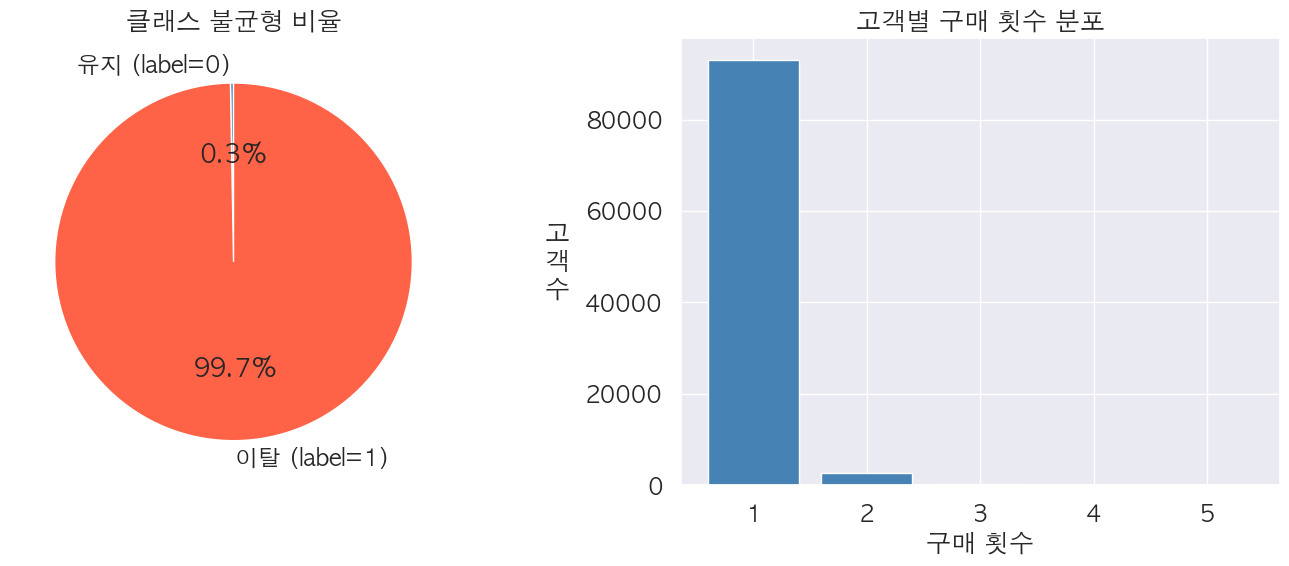

In [5]:
# 구매 횟수 분포
purchase_counts = merged.groupby('customer_unique_id')['order_id'].count()
print("=== 구매 횟수 분포 (상위 10개) ===")
print(purchase_counts.value_counts().head(10))
print(f"\n1회 구매 고객 비율: {(purchase_counts == 1).mean():.1%}")

# 클래스 불균형 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 파이 차트
axes[0].pie(
    [retain_ratio, churn_ratio],
    labels=['유지 (label=0)', '이탈 (label=1)'],
    autopct='%1.1f%%',
    colors=['steelblue', 'tomato'],
    startangle=90
)
axes[0].set_title('클래스 불균형 비율')

# 구매 횟수 분포 (1~5회)
pc_clip = purchase_counts.clip(upper=5).value_counts().sort_index()
axes[1].bar(pc_clip.index.astype(str).tolist(), pc_clip.values,
            color='steelblue', edgecolor='white')
axes[1].set_title('고객별 구매 횟수 분포')
axes[1].set_xlabel('구매 횟수')
axes[1].set_ylabel('고\n객\n수', rotation=0, labelpad=20, verticalalignment='center')

plt.tight_layout()
plt.savefig('../outputs/eda_h1_class_imbalance.png', dpi=150)
plt.show()

---
## [가설] 1. delivered 주문 필터링 및 지연일 계산

In [6]:
# delivered + 날짜 결측 없는 주문만 사용
delivered = orders[
    (orders['order_status'] == 'delivered') &
    (orders['order_delivered_customer_date'].notna()) &
    (orders['order_estimated_delivery_date'].notna())
].copy()

# 지연일 계산 (양수=지연, 음수=조기 배송)
delivered['delay_days'] = (
    delivered['order_delivered_customer_date'] -
    delivered['order_estimated_delivery_date']
).dt.days

print("=== 지연일 통계 ===")
print(delivered['delay_days'].describe().round(2))

# 배송 지연 비율
delay_ratio = (delivered['delay_days'] > 0).mean()
ontime_ratio = (delivered['delay_days'] <= 0).mean()

print("\n=== 배송 지연 비율 ===")
print(f"  지연된 주문 비율     : {delay_ratio:.1%}")
print(f"  정시/빠른 배송 비율  : {ontime_ratio:.1%}")
print(f"  총 delivered 주문 수 : {len(delivered):,}건")

=== 지연일 통계 ===
count    96470.00
mean       -11.88
std         10.18
min       -147.00
25%        -17.00
50%        -12.00
75%         -7.00
max        188.00
Name: delay_days, dtype: float64

=== 배송 지연 비율 ===
  지연된 주문 비율     : 6.8%
  정시/빠른 배송 비율  : 93.2%
  총 delivered 주문 수 : 96,470건


---
## [가설] 2. 지연일 분포 시각화

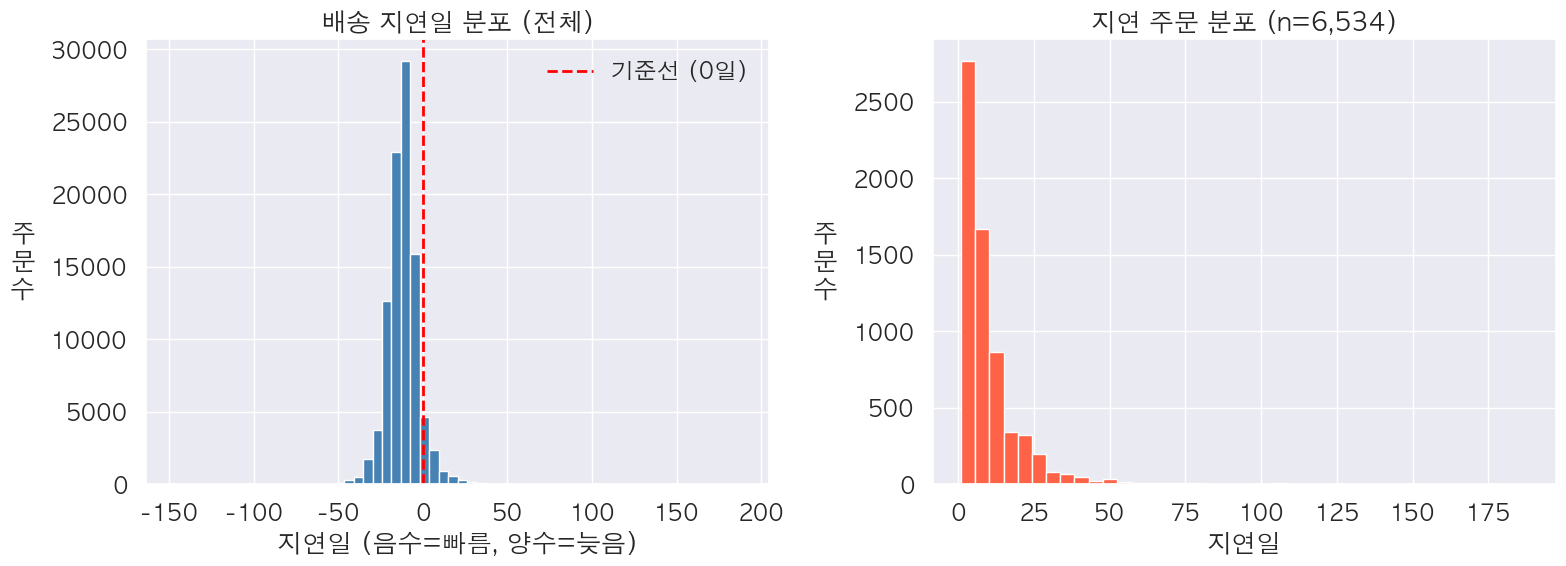

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 전체 분포
axes[0].hist(delivered['delay_days'], bins=60, edgecolor='white', color='steelblue')
axes[0].axvline(0, color='red', linestyle='--', linewidth=2, label='기준선 (0일)')
axes[0].set_title('배송 지연일 분포 (전체)')
axes[0].set_xlabel('지연일 (음수=빠름, 양수=늦음)')
axes[0].set_ylabel('주\n문\n수', rotation=0, labelpad=20, verticalalignment='center')
axes[0].legend()

# 지연 주문만 확대
delayed_only = delivered[delivered['delay_days'] > 0]
axes[1].hist(delayed_only['delay_days'], bins=40, edgecolor='white', color='tomato')
axes[1].set_title(f'지연 주문 분포 (n={len(delayed_only):,})')
axes[1].set_xlabel('지연일')
axes[1].set_ylabel('주\n문\n수', rotation=0, labelpad=20, verticalalignment='center')

plt.tight_layout()
plt.savefig('../outputs/eda_h1_delay_distribution.png', dpi=150)
plt.show()

---
## [가설] 3. 지연 경험 여부 × 이탈률 비교

In [8]:
# customer_unique_id 기준 병합
delivered_merged = delivered.merge(customers, on='customer_id')

# 고객별: 지연 경험 여부, 주문 수
customer_delay = delivered_merged.groupby('customer_unique_id').agg(
    ever_delayed=('delay_days', lambda x: (x > 0).any()),
    order_count =('order_id', 'nunique')
).reset_index()

# cutoff 기준 재구매 여부
cutoff = orders['order_purchase_timestamp'].max() - pd.Timedelta(days=90)
after  = orders.merge(customers, on='customer_id')
after  = after[after['order_purchase_timestamp'] > cutoff]
retained = set(after['customer_unique_id'])

customer_delay['retained'] = customer_delay['customer_unique_id'].isin(retained).astype(int)
customer_delay['churned']  = 1 - customer_delay['retained']

# 그룹별 이탈률
churn_by_delay = customer_delay.groupby('ever_delayed')['churned'].mean()
print("=== 지연 경험 여부별 이탈률 ===")
print(f"  지연 경험 없음 이탈률: {churn_by_delay[False]:.1%}")
print(f"  지연 경험 있음 이탈률: {churn_by_delay[True]:.1%}")
diff = churn_by_delay[True] - churn_by_delay[False]
print(f"  차이 (있음 - 없음)   : {diff:+.1%}")

=== 지연 경험 여부별 이탈률 ===
  지연 경험 없음 이탈률: 90.0%
  지연 경험 있음 이탈률: 92.1%
  차이 (있음 - 없음)   : +2.1%


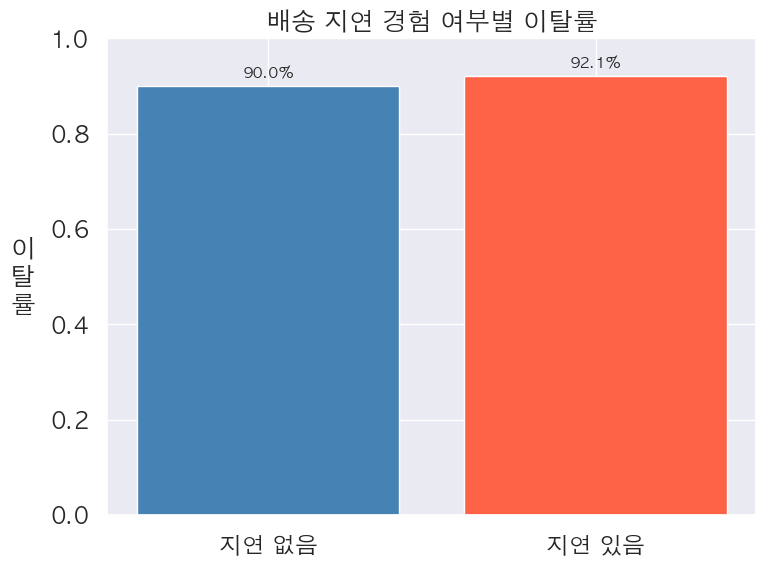

In [9]:
plot_data = churn_by_delay.rename({False: '지연 없음', True: '지연 있음'})

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(plot_data.index, plot_data.values,
               color=['steelblue', 'tomato'], edgecolor='white')
ax.set_title('배송 지연 경험 여부별 이탈률')
ax.set_ylabel('이\n탈\n률', rotation=0, labelpad=20, verticalalignment='center')
ax.set_ylim(0, 1)

# 수치 레이블
for bar, val in zip(bars, plot_data.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{val:.1%}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('../outputs/eda_h1_churn_by_delay.png', dpi=150)
plt.show()

---
## [가설] 4. 지연 구간별 이탈률

In [10]:
# 지연 구간 분류
bins   = [-999, 0, 3, 7, 14, 999]
labels = ['빠름', '0~3일', '3~7일', '7~14일', '14일 초과']

delivered_merged2 = delivered.merge(customers, on='customer_id').copy()
delivered_merged2['delay_group'] = pd.cut(
    delivered_merged2['delay_days'], bins=bins, labels=labels
)

# 고객별 최빈 지연 구간
cust_delay_group = delivered_merged2.groupby('customer_unique_id').agg(
    delay_group=('delay_group', lambda x: x.mode()[0])
).reset_index()
cust_delay_group['churned'] = (
    ~cust_delay_group['customer_unique_id'].isin(retained)
).astype(int)

# 구간별 이탈률
churn_by_group = cust_delay_group.groupby('delay_group', observed=True)['churned'].mean()
count_by_group = cust_delay_group.groupby('delay_group', observed=True)['churned'].count()

print("=== 지연 구간별 이탈률 ===")
for grp in labels:
    if grp in churn_by_group.index:
        print(f"  {grp:10s}: {churn_by_group[grp]:.1%}  (n={count_by_group[grp]:,})")

=== 지연 구간별 이탈률 ===
  빠름        : 90.0%  (n=87,124)
  0~3일      : 86.0%  (n=1,788)
  3~7일      : 91.1%  (n=1,714)
  7~14일     : 96.0%  (n=1,408)
  14일 초과    : 98.1%  (n=1,316)


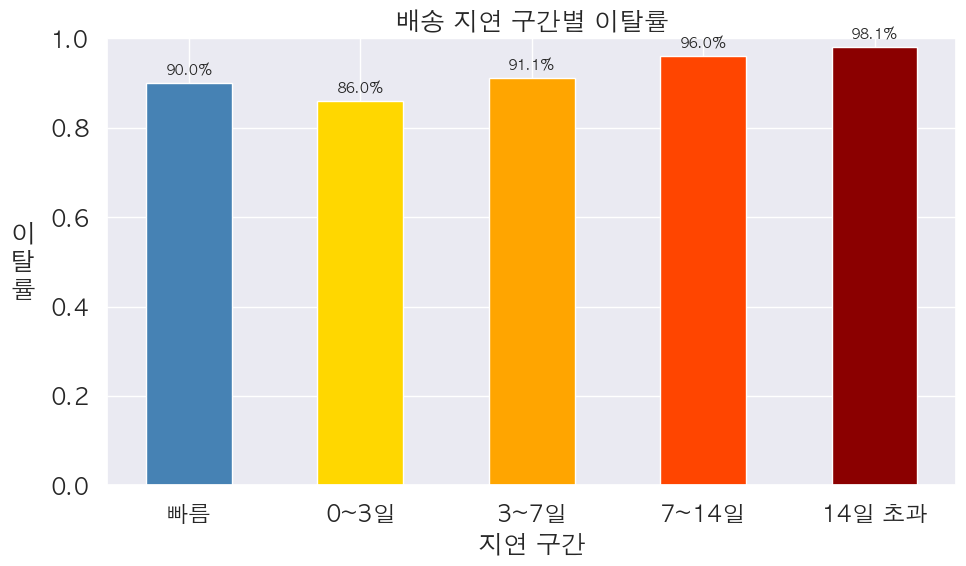

In [11]:
# 구간별 이탈률 시각화
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(
    churn_by_group.index.astype(str),
    churn_by_group.values,
    color=['steelblue', 'gold', 'orange', 'orangered', 'darkred'],
    edgecolor='white',
    width=0.5
)
ax.set_title('배송 지연 구간별 이탈률')
ax.set_ylabel('이\n탈\n률', rotation=0, labelpad=20, verticalalignment='center')
ax.set_xlabel('지연 구간')
ax.set_ylim(0, 1)

for bar, val in zip(bars, churn_by_group.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{val:.1%}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/eda_h1_churn_by_delay_group.png', dpi=150)
plt.show()

---
## [SMOTE] 클래스 균형화 후 배송 지연 구간별 이탈률

> 원본 데이터는 이탈 99.7% : 유지 0.3%로 극단적으로 불균형하여 절대 이탈률 차이가 희석됨.  
> SMOTE로 유지(label=0) 클래스를 오버샘플링해 균형을 맞춘 뒤 배송 지연 패턴을 재확인.

In [12]:
from imblearn.over_sampling import SMOTE

# 고객별 최대 지연일 피처 생성
cust_max_delay = (
    delivered_merged
    .groupby('customer_unique_id')['delay_days']
    .max()
    .reset_index()
    .rename(columns={'delay_days': 'max_delay_days'})
)

# order_count 포함하여 merge
df_cust = (
    cust_delay_group
    .merge(cust_max_delay, on='customer_unique_id')
    .merge(customer_delay[['customer_unique_id', 'order_count']], on='customer_unique_id')
)

X = df_cust[['max_delay_days', 'order_count']].values
y = df_cust['churned'].values

print(f"SMOTE 전  │ label=0(유지): {(y==0).sum():,}  label=1(이탈): {(y==1).sum():,}")

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

print(f"SMOTE 후  │ label=0(유지): {(y_res==0).sum():,}  label=1(이탈): {(y_res==1).sum():,}")

# 합성 샘플 DataFrame 재구성
bins_d   = [-999, 0, 3, 7, 14, 999]
labels_d = ['빠름', '0~3일', '3~7일', '7~14일', '14일 초과']

df_smote = pd.DataFrame({
    'max_delay_days': X_res[:, 0],
    'order_count'   : X_res[:, 1],
    'churned'       : y_res
})
df_smote['delay_group'] = pd.cut(df_smote['max_delay_days'], bins=bins_d, labels=labels_d)

orig_rate  = cust_delay_group.groupby('delay_group', observed=True)['churned'].mean()
smote_rate = df_smote.groupby('delay_group', observed=True)['churned'].mean()
orig_n     = cust_delay_group.groupby('delay_group', observed=True)['churned'].count()
smote_n    = df_smote.groupby('delay_group', observed=True)['churned'].count()

print("\n=== [원본] 지연 구간별 이탈률 ===")
for g in labels_d:
    if g in orig_rate.index:
        print(f"  {g:10s}: {orig_rate[g]:.1%}  (n={orig_n[g]:,})")

print("\n=== [SMOTE 후] 지연 구간별 이탈률 ===")
for g in labels_d:
    if g in smote_rate.index:
        print(f"  {g:10s}: {smote_rate[g]:.1%}  (n={smote_n[g]:,})")

SMOTE 전  │ label=0(유지): 9,211  label=1(이탈): 84,139
SMOTE 후  │ label=0(유지): 84,139  label=1(이탈): 84,139

=== [원본] 지연 구간별 이탈률 ===
  빠름        : 90.0%  (n=87,124)
  0~3일      : 86.0%  (n=1,788)
  3~7일      : 91.1%  (n=1,714)
  7~14일     : 96.0%  (n=1,408)
  14일 초과    : 98.1%  (n=1,316)

=== [SMOTE 후] 지연 구간별 이탈률 ===
  빠름        : 49.6%  (n=157,572)
  0~3일      : 40.4%  (n=3,956)
  3~7일      : 51.7%  (n=3,148)
  7~14일     : 71.2%  (n=1,982)
  14일 초과    : 83.0%  (n=1,620)


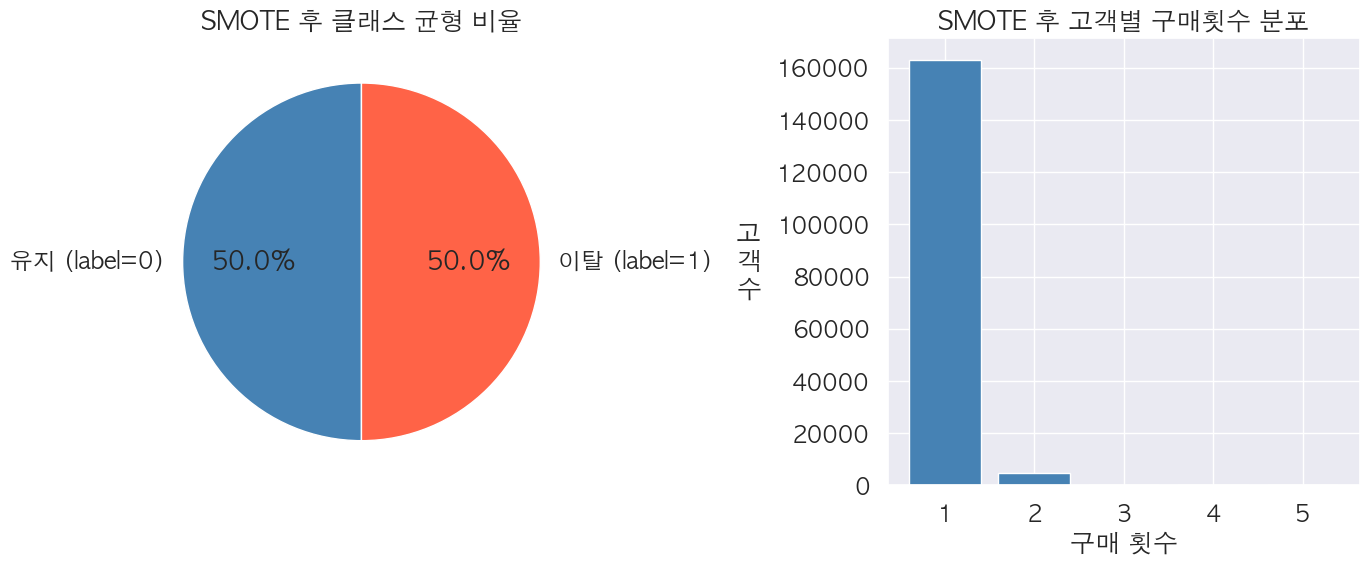

In [13]:
smote_total  = len(y_res)
retain_ratio_s = (y_res == 0).sum() / smote_total
churn_ratio_s  = (y_res == 1).sum() / smote_total

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 파이차트: 클래스 균형
axes[0].pie(
    [retain_ratio_s, churn_ratio_s],
    labels=['유지 (label=0)', '이탈 (label=1)'],
    autopct='%1.1f%%',
    colors=['steelblue', 'tomato'],
    startangle=90
)
axes[0].set_title('SMOTE 후 클래스 균형 비율')

# 막대그래프: 구매횟수 분포 (1~5회 클립)
pc_smote = df_smote['order_count'].clip(upper=5).round().astype(int)
pc_clip  = pc_smote.value_counts().sort_index()
axes[1].bar(pc_clip.index.astype(str).tolist(), pc_clip.values,
            color='steelblue', edgecolor='white')
axes[1].set_title('SMOTE 후 고객별 구매횟수 분포')
axes[1].set_xlabel('구매 횟수')
axes[1].set_ylabel('고\n객\n수', rotation=0, labelpad=20, verticalalignment='center')

plt.tight_layout()
plt.savefig('../outputs/eda_h1_smote_class_balance.png', dpi=150)
plt.show()

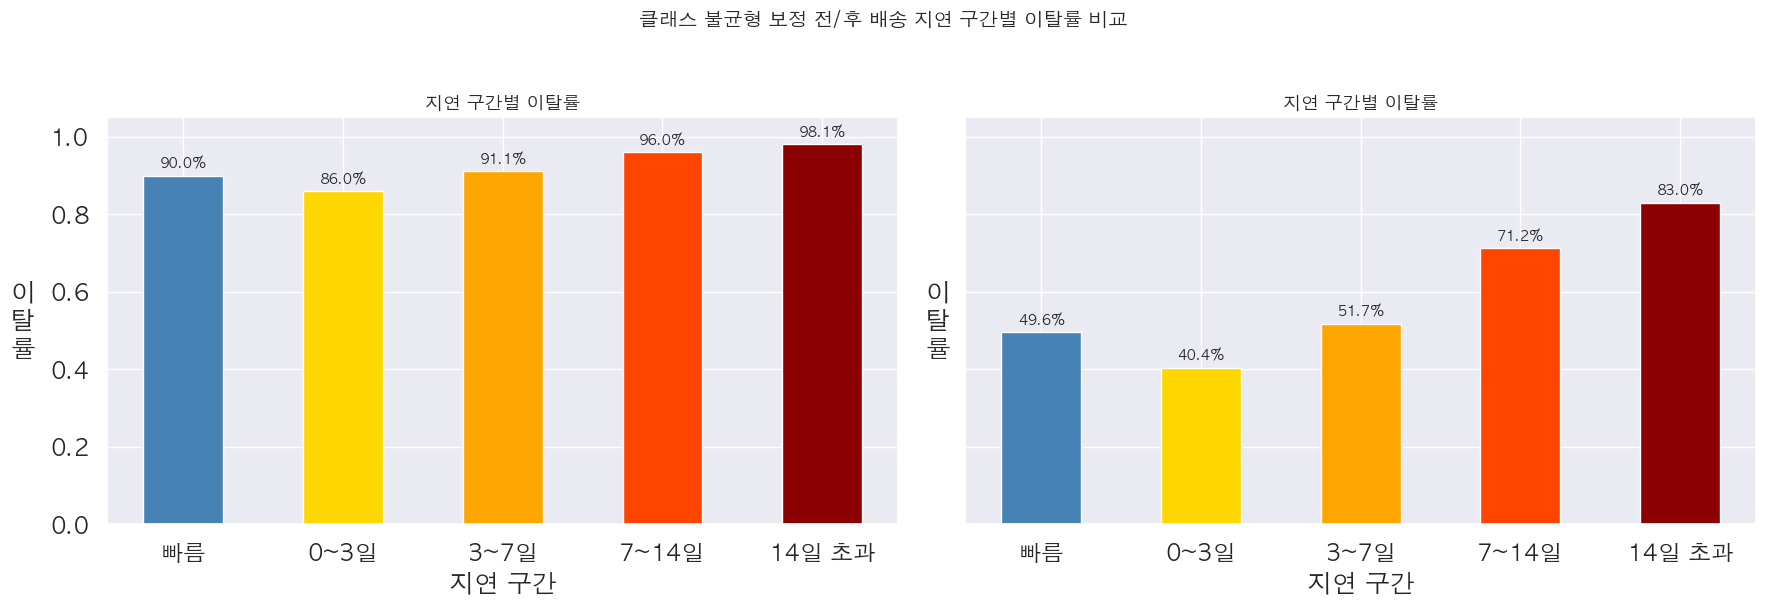

In [14]:
bar_colors = ['steelblue', 'gold', 'orange', 'orangered', 'darkred']

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
for ax, rate in zip(axes, [orig_rate, smote_rate]):
    vals = [rate.get(g, 0) for g in labels_d]
    bars = ax.bar(labels_d, vals, color=bar_colors, edgecolor='white', width=0.5)
    ax.set_title('지연 구간별 이탈률', fontsize=13)
    ax.set_xlabel('지연 구간')
    ax.set_ylabel('이\n탈\n률', rotation=0, labelpad=20, verticalalignment='center')
    ax.set_ylim(0, 1.05)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.1%}', ha='center', va='bottom', fontsize=10)

plt.suptitle('클래스 불균형 보정 전/후 배송 지연 구간별 이탈률 비교', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/eda_h1_smote_delay_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 체크 포인트 & 결론 정리

In [15]:
print("=" * 50)
print("EDA 가설1 요약")
print("=" * 50)

print(f"\n[클래스 불균형]")
print(f"  이탈 비율 (label=1) : {churn_ratio:.1%}")
print(f"  유지 비율 (label=0) : {retain_ratio:.1%}")

print(f"\n[배송 지연 비율]")
print(f"  지연 주문 비율 : {delay_ratio:.1%}")

print(f"\n[가설1 결론 — 원본 (불균형)]")
diff_abs = abs(churn_by_delay[True] - churn_by_delay[False])
print(f"  지연 없음 이탈률: {churn_by_delay[False]:.1%}")
print(f"  지연 있음 이탈률: {churn_by_delay[True]:.1%}")
print(f"  이탈률 차이    : {diff_abs:.1%}  ← 99.7% 이탈 기저율로 차이 희석됨")

print(f"\n[가설1 결론 — SMOTE 균형화 후 (label=0:1 = 1:1)]")
print(f"  {'구간':<10s}  {'원본':>6s}  {'SMOTE후':>7s}  {'변화':>5s}")
print(f"  {'-'*38}")
for g in labels_d:
    if g in orig_rate.index and g in smote_rate.index:
        diff_g = smote_rate[g] - orig_rate[g]
        print(f"  {g:<10s}  {orig_rate[g]:>6.1%}  {smote_rate[g]:>7.1%}  {diff_g:>+5.1%}")

print(f"\n  → SMOTE 균형화 후 지연 구간이 길수록 이탈률 상승 패턴이 명확해짐")
print(f"  → 가설1(배송 지연 → 이탈) 지지됨")

EDA 가설1 요약

[클래스 불균형]
  이탈 비율 (label=1) : 99.7%
  유지 비율 (label=0) : 0.3%

[배송 지연 비율]
  지연 주문 비율 : 6.8%

[가설1 결론 — 원본 (불균형)]
  지연 없음 이탈률: 90.0%
  지연 있음 이탈률: 92.1%
  이탈률 차이    : 2.1%  ← 99.7% 이탈 기저율로 차이 희석됨

[가설1 결론 — SMOTE 균형화 후 (label=0:1 = 1:1)]
  구간              원본   SMOTE후     변화
  --------------------------------------
  빠름           90.0%    49.6%  -40.4%
  0~3일         86.0%    40.4%  -45.6%
  3~7일         91.1%    51.7%  -39.4%
  7~14일        96.0%    71.2%  -24.7%
  14일 초과       98.1%    83.0%  -15.1%

  → SMOTE 균형화 후 지연 구간이 길수록 이탈률 상승 패턴이 명확해짐
  → 가설1(배송 지연 → 이탈) 지지됨
